# **[CH10 시각화]**

# **03 시본**


## <정보의 종류에 따른 시각화 차트 유형>

히스토그램
-연속형 값에 대한 도수 분포

바 플롯
-특정 칼럼의 이산 값에 따른 다른 칼럼의 연속형 값을 막대 그래프로 시각화

박스 플롯
-연속형 값의 사분위 IQR, 최대, 최소, 이상치 값을 시각화

바이올린 플롯
-히스토그램의 연속 확률 분포 곡선과 박스 플롯을 바이올린 형태로 시각화

스캐터 플롯
-산점도, 2개의 연속형 값들을 x,y 좌표상의 점으로 시각화

상관 히트맵
-다수의 연속형 칼럼들에 대해서 상호 간의 상관 관계를 시각화



시본 : x,y축으로 구성된 이차원 축에서 데이터를 시각화, 2개의 변수(칼럼)에 대한 정보를 기본적으로 표출, 시본의 대부분 시각화 함수들은 hue인자를 통해 또는 플롯의 유형에 따라 연속형 데이터의 정보를 다른 이산형 데이터 값으로 만들어줘서 2개가 아닌 여러 변수로도 시각화 가능 



## <히스토그램>

연속형 값을 범위 또는 구간으로 그룹화해 개별 구간에 해당되는 데이터의 건수(도수)를 시각화 
histplot() - Axes 레벨 함수
displot() - Figure 레벨 함수 


In [1]:
import pandas as pd

#파일을 DataFrame으로 생성하고 객체 할당 
titanic_df=pd.read_csv(r'C:\Users\chkwon\Data_Handling\titanic_train.csv')
titanic_df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
1) histplot() 함수 활용

- 시본에서는 DataFrame을 입력값으로 받으면 자동으로 칼럼명을 해석해서 X축명 또는 Y축명에 할당
- 그림에서 보듯이 별도의 xlabel() 호출 없이도 자동으로 Age 칼럼을 X축명에 할당하였고, 
- 히스토그램 시각화이므로 Y축명에 도수를 나타내는 Count를 설정
- bin으로 구간 개수 설정 

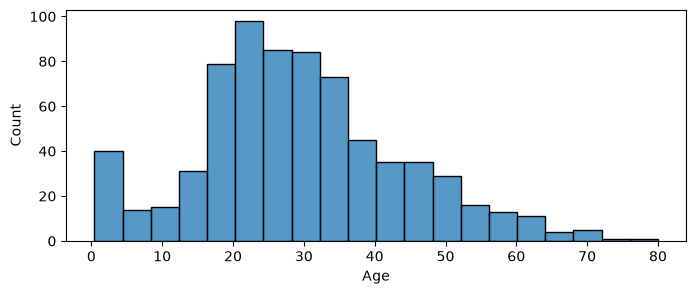

In [4]:
import matplotlib.pyplot as plt 
import seaborn as sns

# 시본에서도 plt.figure()의 figsize 인자를 입력하여 전체 Figure의 크기 조절 
plt.figure(figsize=(8, 3))

# 타이타닉 승객의 나이를 히스토그램으로 시각화 
# DataFrame의 칼럼명을 자동으로 인식해서 xlabel 값을 할당. ylabel 값은 Count로 설정. 
# bin=구간 개수 설정 
sns.histplot(titanic_df['Age'], bins=20) 
plt.show()

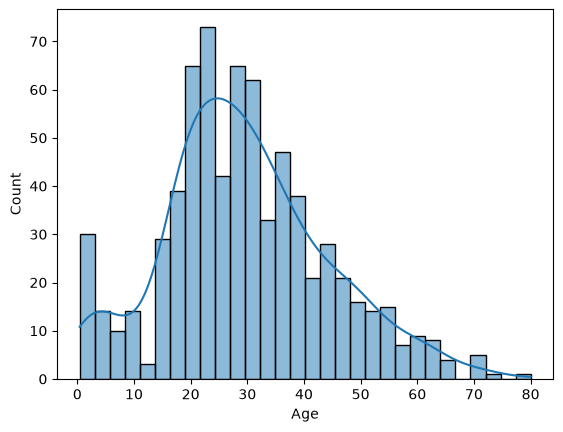

In [3]:
#y인자는 생략하고 x인자와 data인자를 설정
#kde=True를 설정해 히스토그램의 연속 확률분포 곡선 시각화 
sns.histplot(x='Age', data=titanic_df, bins=30, kde=True) 
plt.show()

In [ ]:
2) displot() 함수 활용

-  Figure 레벨 함수의 특징은 맷플롯립 API 사용을 최소화, 
기본 맷플롯립에서 사용하는 기능들을 figure 레벨 함수의 인자 등으로 대체 
-> plt.figure() 사용 불가   


<Figure size 800x400 with 0 Axes>

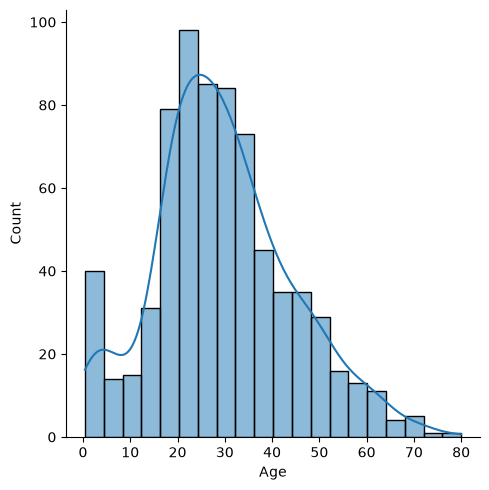

In [5]:
import seaborn as sns

# seaborn의 figure레벨 그래프는 plt.figure( )로 Figure 크기를 조절할 수 없습니다. 
plt.figure(figsize=(8, 4)) 
sns.displot(x='Age', data=titanic_df, kde=True) 
plt.show()

displot()함수의 Figure 크기를 조절하기 위한 인자
->plt.figure()함수 사용 x
-height : 세로(높이)
-aspect : 가로와 세로의 배율.
-height*aspect : 가로 

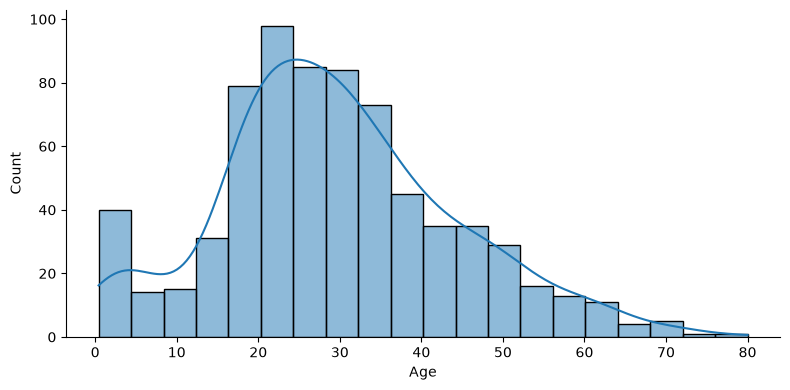

In [6]:
import seaborn as sns

#가로가 8, 세로가 4인 그래프 
sns.displot(titanic_df['Age'], kde=True, height=4, aspect=2) 
plt.show()

## <카운트 플롯>

-막대그래프 : 이산형 값에 대한 건수(도수)

-countplot() 함수 사용

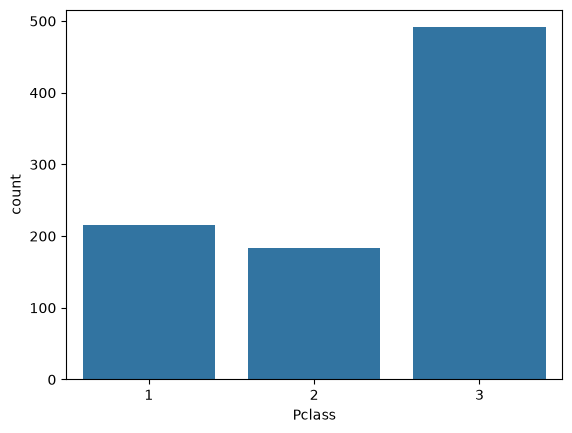

In [7]:
sns.countplot(x='Pclass', data=titanic_df)
plt.show()

## <바 플롯>

-막대그래프
-x축은 이산형 값, y축은 평균이나 총합으로 표현되는 연속형 값


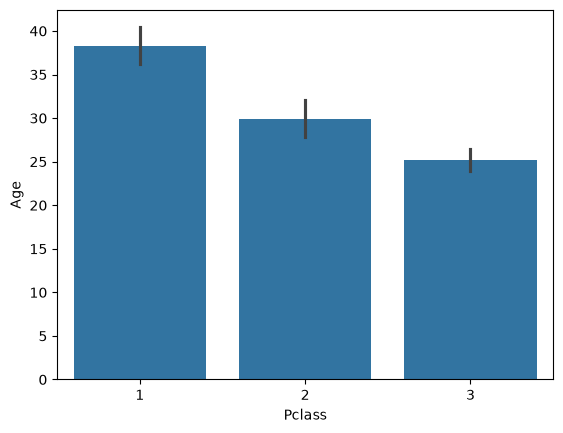

In [8]:
# 자동으로 xlabel, ylabel을 barplot( )의 x 인자값인 Pclass, y 인자값이 Age로 설정. 
# 타이타닉 pclass의 1,2,3값별 age의 평균값을 나타낸 바플롯
sns.barplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

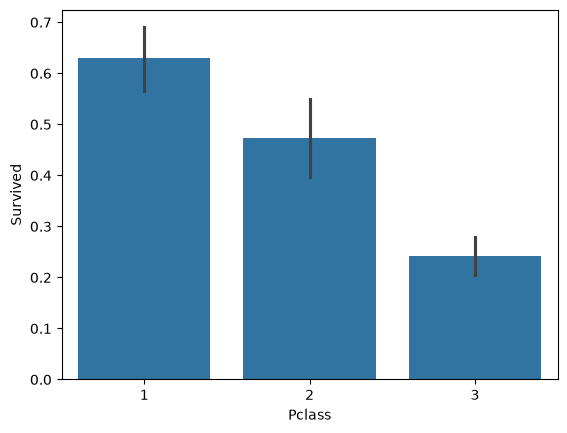

In [9]:
#pclass별 survived의 평균 막대그래프
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.show()

수평/수직 막대 그래프 설정
orient인자 - v(수직), h(수평)
->인자를 설정하지 않으면 x,y축의 데이터유형으로 판단, 모두 숫자형이면 수직 막대 그래프 우선 

y의 연속형 값 표현 설정
estimator인자 - sum 등
->인자를 설정하지 않으면 y의 평균값으로 계산됨


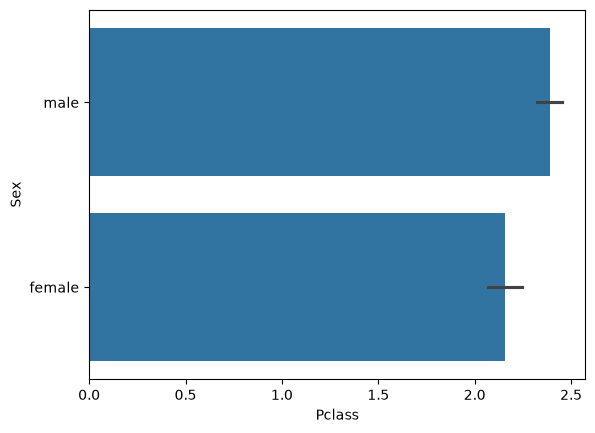

In [10]:
### y축을 문자값으로 설정하면 자동으로 수평 막대 그래프 변환
sns.barplot(x='Pclass', y='Sex', data=titanic_df)
plt.show()

<Axes: xlabel='Name', ylabel='Sex'>

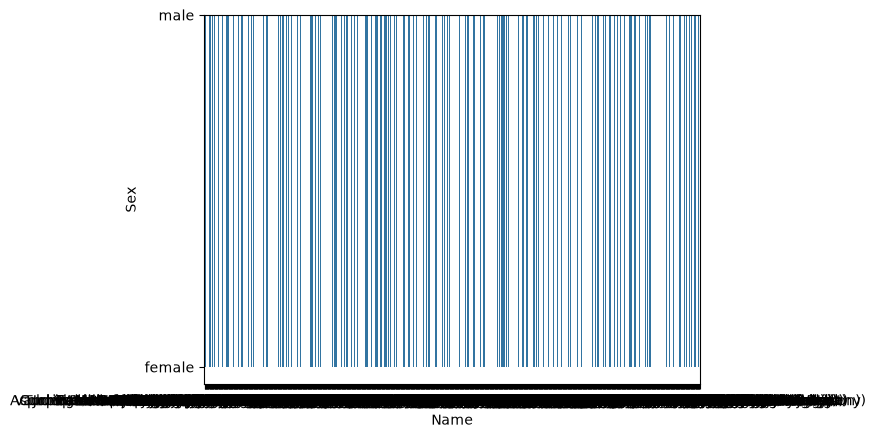

In [20]:
# x 인자로 문자열인 Name을, y 인자로 문자열인 Sex를 입력하므로 barplot은 오류를 발생.
sns.barplot(x='Name', y='Sex', data=titanic_df)

C:\Users\user\AppData\Local\Temp\ipykernel_19016\638921997.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum)


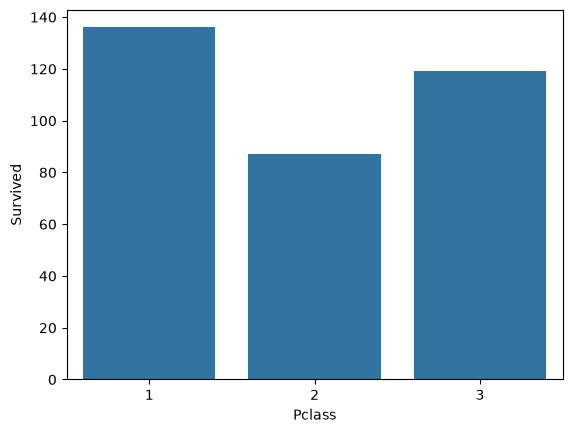

In [21]:
# estimator=sum을 적용하여 평균이 아니라 총합으로 표현.
sns.barplot(x='Pclass', y='Survived', data=titanic_df, ci=None, estimator=sum) 
plt.show()

## <barplot()함수의 hue인자를 사용하여 시각화 정보를 추가적 세분화>

hue인자의 활용 

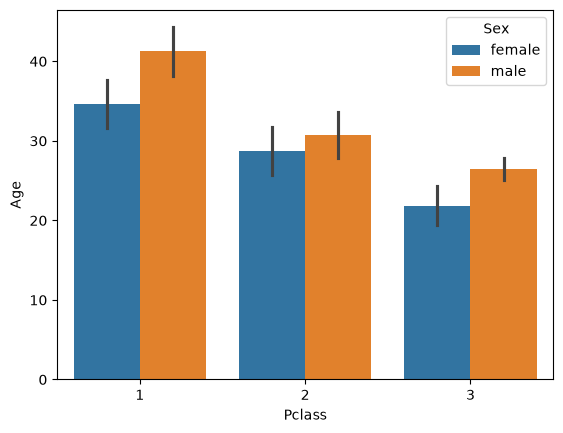

In [23]:
# 아래는 Pclass가 X축값이며 hue파라미터로 Sex를 설정
# 개별 Pclass 값별로 Sex에 따른 Age 평균 값을 구함.
sns.barplot(x='Pclass', y='Age', hue='Sex', data=titanic_df) 
plt.show()

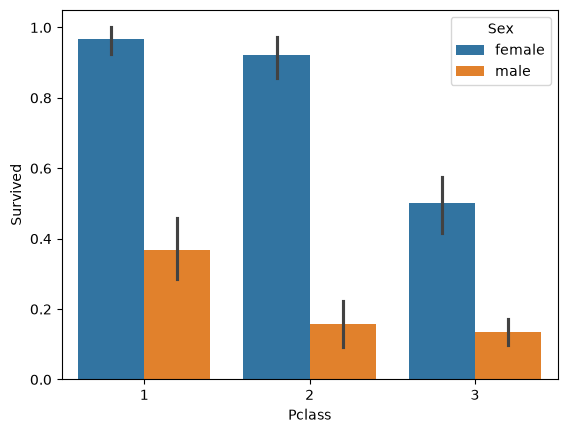

In [25]:
# 개별 Pclass 값별로 Sex에 따른 Survived 평균값을 구함.
# Pclass가 X축 값이며 Survived가、(축 값. hue 파라미터로 Sex를 설정 
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df) 
plt.show()

## <박스 플롯>


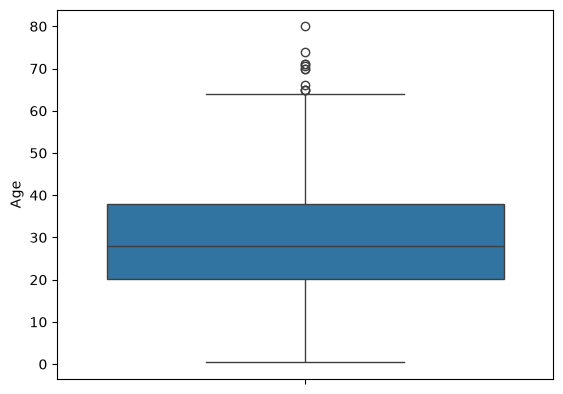

In [26]:
sns.boxplot(y='Age', data=titanic_df) 
plt.show()

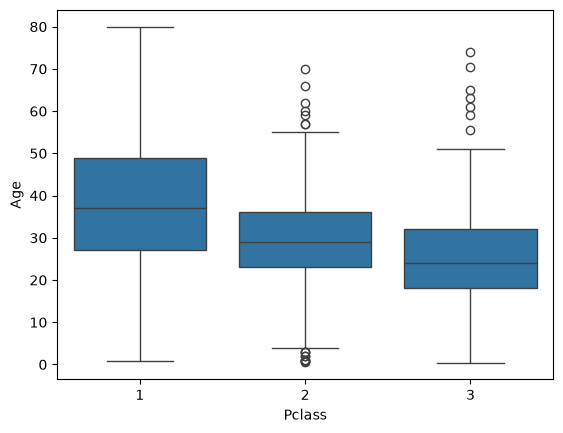

In [27]:
sns.boxplot(x='Pclass', y='Age', data=titanic_df) 
plt.show()

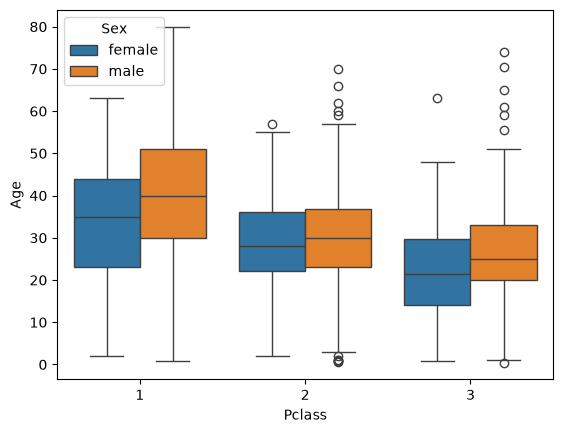

In [28]:
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic_df) 
plt.show()

## <바이올린 플롯>


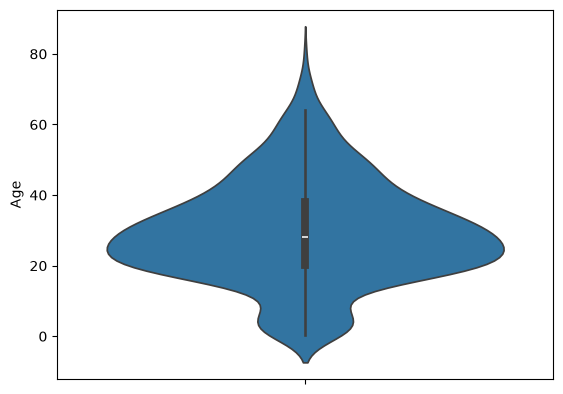

In [29]:
# Age 칼럼에 대한 수직 바이올린 플롯 시각화 
sns.violinplot(y='Age', data=titanic_df) 
plt.show()

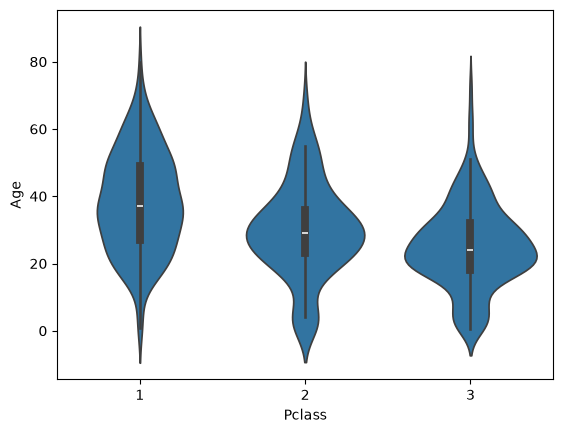

In [30]:
# x축값인 Pclass의 값별로 y축 값인 Age의 바이올린 플롯을 그림
# pClass값별 Age 데이터 분포를 비교하여 볼 수 있음.
sns.violinplot(x='Pclass', y='Age', data=titanic_df)
plt.show()

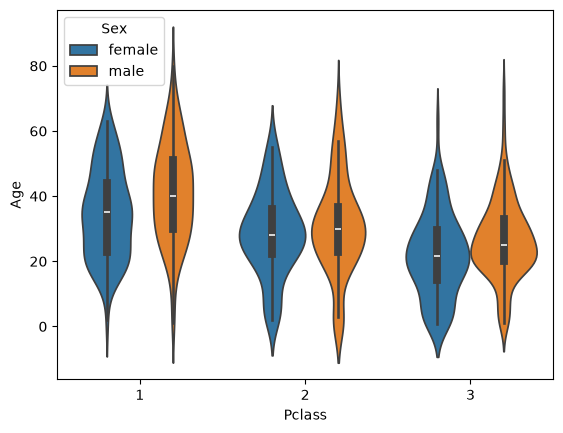

In [31]:
# x축값인 개별 Pclass 내에서 Sex값별로 y축 값인 Age의 바이올린 플롯을 그림 
sns.violinplot(x='Pclass', y='Age', hue='Sex', data=titanic_df) 
plt.show()

## <subplots를 이용하여 시본의 다양한 그래프를 시각화>


index: 0
index: 1
index: 2


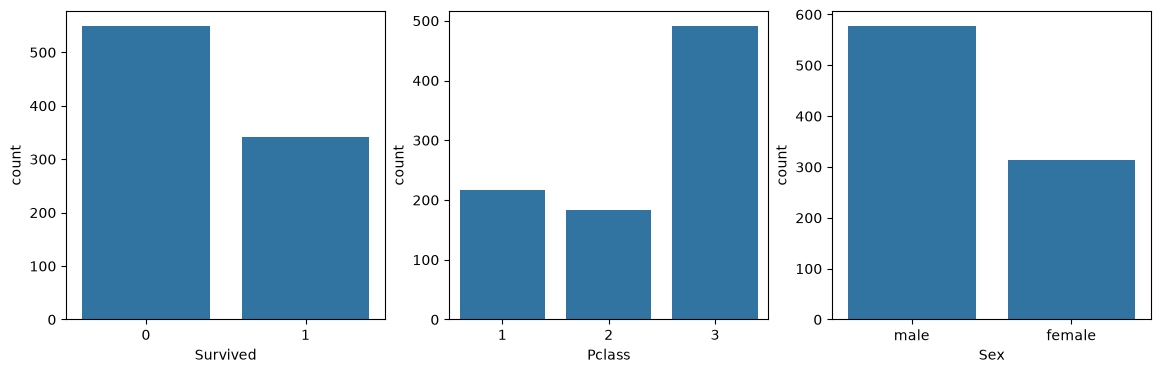

In [32]:
cat_columns = ['Survived', 'Pclass', 'Sex']

# nrows는 1 이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
    print('index:', index)
    # seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
    sns.countplot(x=column, data=titanic_df, ax=axs[index])

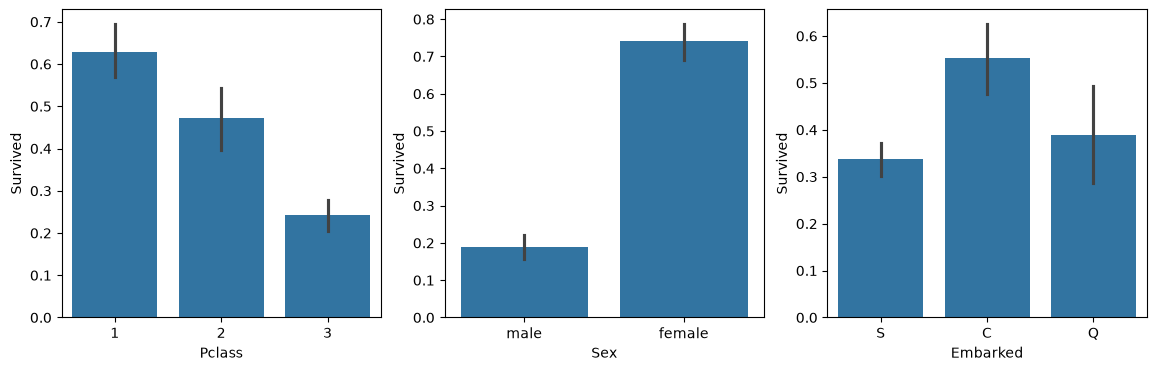

In [33]:
cat_columns = ['Pclass', 'Sex', 'Embarked']

# nrows는 1 이고 ncols는 칼럼의 개수만큼인 subplots을 설정.
fig, axs = plt.subplots(nrows=1, ncols=len(cat_columns), figsize=(14, 4))

for index, column in enumerate(cat_columns):
    # seaborn의 Axes 레벨 function들은 ax 인자로 subplots의 어느 Axes에 위치할지 설정.
    sns.barplot(x=column, y='Survived', data=titanic_df, ax=axs[index])

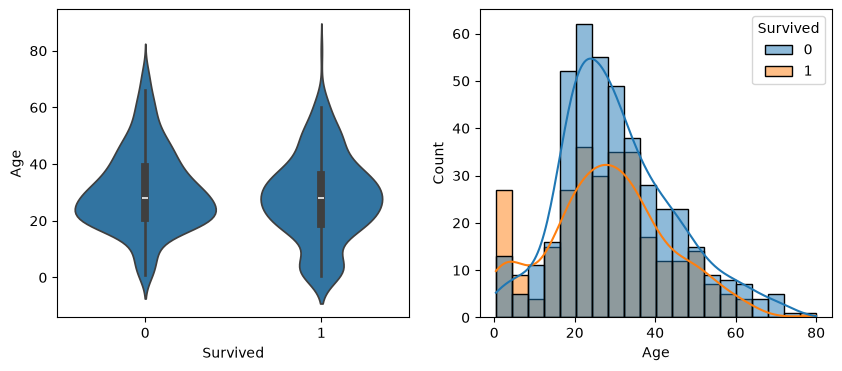

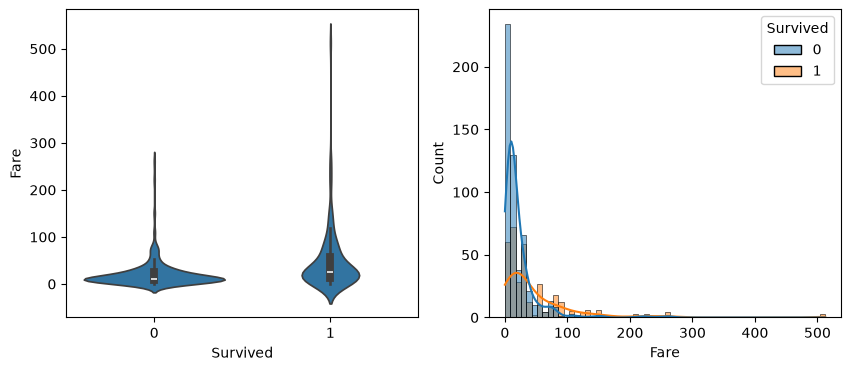

In [35]:
cont_columns = ['Age', 'Fare']

# 리스트로 할당된 칼럼들의 개수만큼 루프 수행. 
for column in cont_columns:
    
    # 왼쪽에는 바이올린 플롯, 오른쪽에는 히스토그램을 시각화. nrows는 1, ncols=2인 서브플롯 생성.
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    # 왼쪽 Axes 객체에는 Survived값 0, 1 별 개별 칼럼의 바이올린 플롯 시각화.
    sns.violinplot(x='Survived', y=column, data=titanic_df, ax=axs[0])
    # 오른쪽 Axes 객체에는 Survived 값에 따른 개별 칼럼의 히스토그램 시각화
    sns.histplot(x=column, data=titanic_df, kde=True, hue='Survived', ax=axs[1])

## <산점도, 스캐터 플롯>


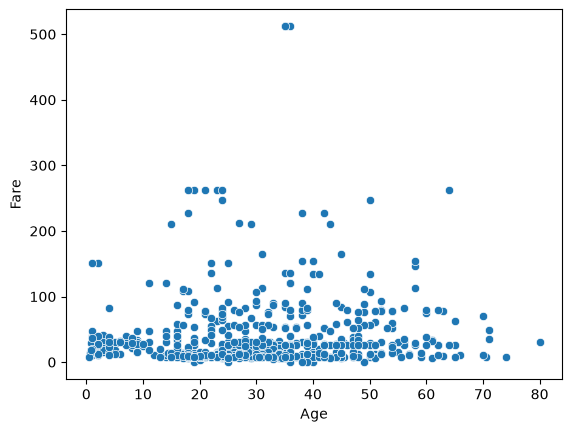

In [36]:
# 수축값으로 Age를, 우축값으로 Fare를 설정
sns.scatterplot(x='Age', y='Fare', data=titanic_df) 
plt.show()

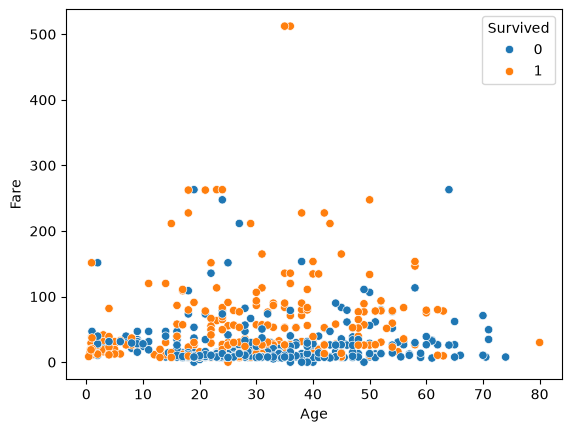

In [37]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=titanic_df) 
plt.show()

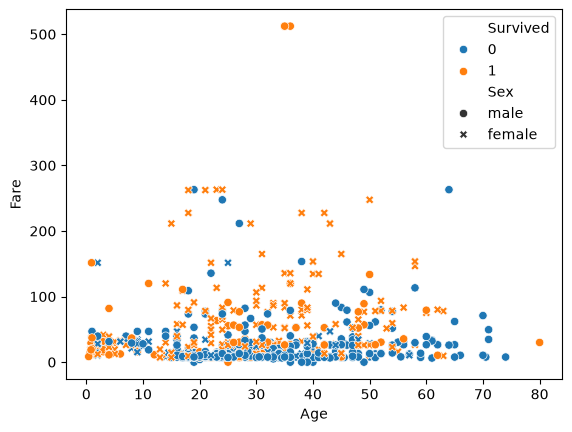

In [38]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', style='Sex', data=titanic_df) 
plt.show()

## <상관 히트맵>


In [41]:
corr_df = titanic_df.corr(numeric_only=True)
corr_df

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


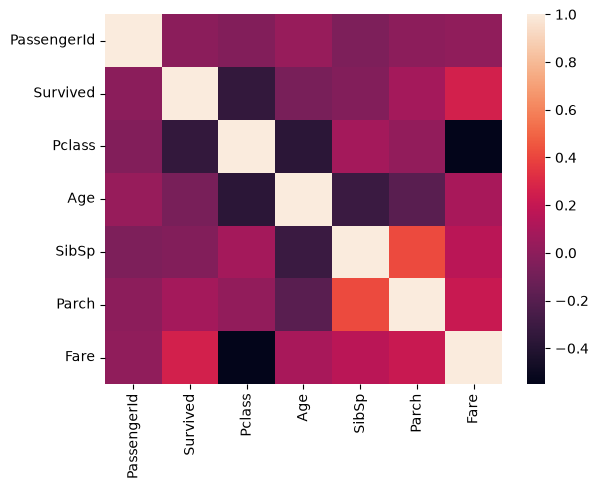

In [44]:
corr = titanic_df.corr(numeric_only=True) 
sns.heatmap(corr) 
plt.show()

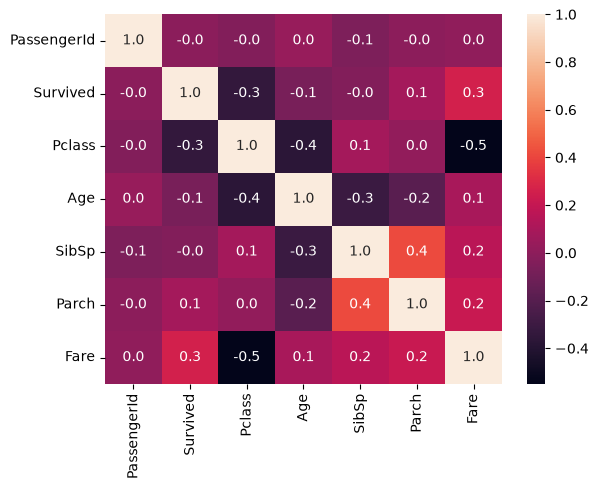

In [45]:
sns.heatmap(corr, annot=True, fmt='.1f', cbar=True) 
plt.show()